In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib



 1. Data Loading and Preparation

In [2]:


df = pd.read_csv('kidney_donor_dataset.csv')
print(f"Dataset shape: {df.shape}")


if 'match_label' in df.columns:
    target_col = 'match_label'
elif 'Suitability' in df.columns:
    target_col = 'Suitability'
else:
    target_col = df.columns[-1]


if df[target_col].dtype == 'object':
    df['target'] = df[target_col].apply(lambda x: 1 if 'Suitable' in str(x) else 0)
else:
    df['target'] = df[target_col]

print(f"Target column: {target_col}")
print(f"\nClass distribution:")
print(df['target'].value_counts())
print(f"Balance: {df['target'].value_counts(normalize=True).to_dict()}")

Dataset shape: (1500, 17)
Target column: Suitability

Class distribution:
target
1    915
0    585
Name: count, dtype: int64
Balance: {1: 0.61, 0: 0.39}


2. Feature Engineering and Preprocessing



In [3]:

exclude_cols = ['target', target_col, 'donor_id', 'Donor_ID', 'Recipient_ID']
feature_cols = [col for col in df.columns if col not in exclude_cols]


numeric_features = df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline created")

Numeric features: 16
Categorical features: 0
Preprocessing pipeline created


3. Model Training



In [4]:
 
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_split=15,
        min_samples_leaf=10,
        random_state=42
    ))
])


model_pipeline.fit(X_train, y_train)
print("\nModel training complete")

Training set: 1125 samples
Test set: 375 samples

Model training complete


4. Model Evaluation



In [5]:
# Generate predictions
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]


acc = accuracy_score(y_test, y_pred)
roc_val = roc_auc_score(y_test, y_probs)

print("="*60)
print("MODEL PERFORMANCE REPORT")
print("="*60)
print(f"\nROC-AUC Score: {roc_val:.4f}")
print(f"Accuracy: {acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"TN: {cm[0,0]:4d}  |  FP: {cm[0,1]:4d}")
print(f"FN: {cm[1,0]:4d}  |  TP: {cm[1,1]:4d}")
print("="*60)

MODEL PERFORMANCE REPORT

ROC-AUC Score: 0.7790
Accuracy: 78.13%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.88      0.51      0.64       146
    Suitable       0.75      0.96      0.84       229

    accuracy                           0.78       375
   macro avg       0.82      0.73      0.74       375
weighted avg       0.80      0.78      0.76       375


Confusion Matrix:
TN:   74  |  FP:   72
FN:   10  |  TP:  219


In [6]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Store Random Forest results
rf_acc = acc
rf_roc = roc_val
rf_y_pred = y_pred
rf_y_probs = y_probs

print("Random Forest results stored for comparison")

Random Forest results stored for comparison


Model 1: Logistic Regression

In [7]:
# Create Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


lr_pipeline.fit(X_train, y_train)

# Generate predictions
lr_y_pred = lr_pipeline.predict(X_test)
lr_y_probs = lr_pipeline.predict_proba(X_test)[:, 1]


lr_acc = accuracy_score(y_test, lr_y_pred)
lr_roc = roc_auc_score(y_test, lr_y_probs)

print("="*60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {lr_roc:.4f}")
print(f"Accuracy: {lr_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, lr_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_y_pred)
print(f"TN: {lr_cm[0,0]:4d}  |  FP: {lr_cm[0,1]:4d}")
print(f"FN: {lr_cm[1,0]:4d}  |  TP: {lr_cm[1,1]:4d}")
print("="*60)

LOGISTIC REGRESSION PERFORMANCE

ROC-AUC Score: 0.7840
Accuracy: 73.33%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.65      0.68      0.67       146
    Suitable       0.79      0.76      0.78       229

    accuracy                           0.73       375
   macro avg       0.72      0.72      0.72       375
weighted avg       0.74      0.73      0.73       375


Confusion Matrix:
TN:  100  |  FP:   46
FN:   54  |  TP:  175


### Model 2: Gradient Boosting Classifier

In [8]:

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


gb_pipeline.fit(X_train, y_train)


gb_y_pred = gb_pipeline.predict(X_test)
gb_y_probs = gb_pipeline.predict_proba(X_test)[:, 1]


gb_acc = accuracy_score(y_test, gb_y_pred)
gb_roc = roc_auc_score(y_test, gb_y_probs)

print("="*60)
print("GRADIENT BOOSTING PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {gb_roc:.4f}")
print(f"Accuracy: {gb_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, gb_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
gb_cm = confusion_matrix(y_test, gb_y_pred)
print(f"TN: {gb_cm[0,0]:4d}  |  FP: {gb_cm[0,1]:4d}")
print(f"FN: {gb_cm[1,0]:4d}  |  TP: {gb_cm[1,1]:4d}")
print("="*60)

GRADIENT BOOSTING PERFORMANCE

ROC-AUC Score: 0.7779
Accuracy: 78.13%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.83      0.55      0.66       146
    Suitable       0.76      0.93      0.84       229

    accuracy                           0.78       375
   macro avg       0.80      0.74      0.75       375
weighted avg       0.79      0.78      0.77       375


Confusion Matrix:
TN:   80  |  FP:   66
FN:   16  |  TP:  213


Model 3: Support Vector Machine 

In [9]:

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])


svm_pipeline.fit(X_train, y_train)


svm_y_pred = svm_pipeline.predict(X_test)
svm_y_probs = svm_pipeline.predict_proba(X_test)[:, 1]


svm_acc = accuracy_score(y_test, svm_y_pred)
svm_roc = roc_auc_score(y_test, svm_y_probs)

print("="*60)
print("SUPPORT VECTOR MACHINE PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {svm_roc:.4f}")
print(f"Accuracy: {svm_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, svm_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
svm_cm = confusion_matrix(y_test, svm_y_pred)
print(f"TN: {svm_cm[0,0]:4d}  |  FP: {svm_cm[0,1]:4d}")
print(f"FN: {svm_cm[1,0]:4d}  |  TP: {svm_cm[1,1]:4d}")
print("="*60)

SUPPORT VECTOR MACHINE PERFORMANCE

ROC-AUC Score: 0.7677
Accuracy: 76.80%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.87      0.47      0.61       146
    Suitable       0.74      0.96      0.83       229

    accuracy                           0.77       375
   macro avg       0.81      0.71      0.72       375
weighted avg       0.79      0.77      0.75       375


Confusion Matrix:
TN:   69  |  FP:   77
FN:   10  |  TP:  219


 4.3. Model Comparison and Selection




In [10]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression', 'Gradient Boosting', 'SVM (RBF)'],
    'Accuracy': [rf_acc, lr_acc, gb_acc, svm_acc],
    'ROC-AUC': [rf_roc, lr_roc, gb_roc, svm_roc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Select best model based on ROC-AUC
best_idx = comparison_df['ROC-AUC'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_roc_auc = comparison_df.loc[best_idx, 'ROC-AUC']
best_accuracy = comparison_df.loc[best_idx, 'Accuracy']

print(f"\n SELECTED MODEL: {best_model_name}")
print(f"   ROC-AUC: {best_roc_auc:.4f}")
print(f"   Accuracy: {best_accuracy * 100:.2f}%")
print("="*70)


model_map = {
    'Random Forest': model_pipeline,
    'Logistic Regression': lr_pipeline,
    'Gradient Boosting': gb_pipeline,
    'SVM (RBF)': svm_pipeline
}

final_model = model_map[best_model_name]
print(f"\nFinal model pipeline ready for deployment")

MODEL COMPARISON SUMMARY
              Model  Accuracy  ROC-AUC
Logistic Regression  0.733333 0.783992
      Random Forest  0.781333 0.779027
  Gradient Boosting  0.781333 0.777891
          SVM (RBF)  0.768000 0.767677

 SELECTED MODEL: Logistic Regression
   ROC-AUC: 0.7840
   Accuracy: 73.33%

Final model pipeline ready for deployment


 5. Final Model Persistence



In [11]:
# Save final selected model
model_name_short = best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
model_filename = f'donor_match_model.pkl'

joblib.dump(final_model, model_filename)

print(f"Final model saved: {model_filename}")
print(f"Model type: {best_model_name}")
print(f"Performance: ROC-AUC = {best_roc_auc:.4f}, Accuracy = {best_accuracy * 100:.2f}%")

Final model saved: donor_match_model.pkl
Model type: Logistic Regression
Performance: ROC-AUC = 0.7840, Accuracy = 73.33%


6. Model Comparison Visualization

Visualization saved: model_comparison_analysis.png


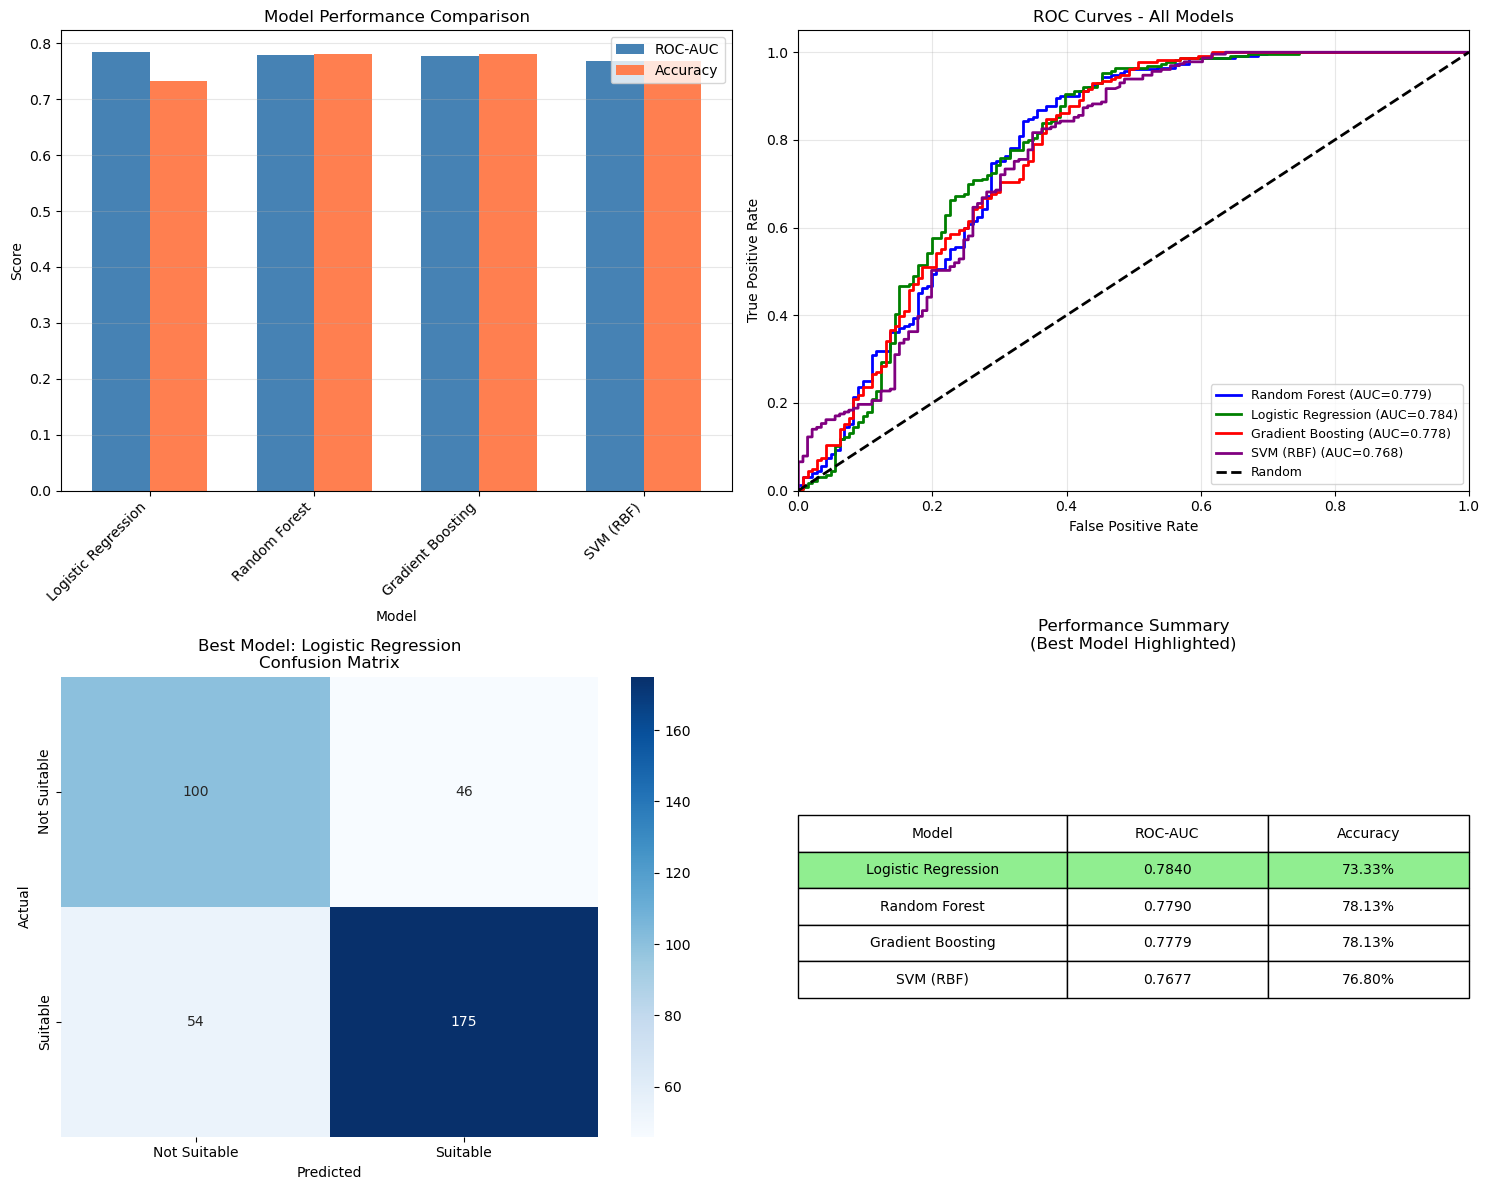

In [12]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['ROC-AUC'], width, label='ROC-AUC', color='steelblue')
ax1.bar(x_pos + width/2, comparison_df['Accuracy'], width, label='Accuracy', color='coral')
ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)


ax2 = axes[0, 1]
models_data = [
    ('Random Forest', rf_y_probs, rf_roc, 'blue'),
    ('Logistic Regression', lr_y_probs, lr_roc, 'green'),
    ('Gradient Boosting', gb_y_probs, gb_roc, 'red'),
    ('SVM (RBF)', svm_y_probs, svm_roc, 'purple')
]

for name, probs, roc, color in models_data:
    fpr_temp, tpr_temp, _ = roc_curve(y_test, probs)
    ax2.plot(fpr_temp, tpr_temp, lw=2, label=f'{name} (AUC={roc:.3f})', color=color)

ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves - All Models')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)


ax3 = axes[1, 0]
best_cm_map = {
    'Random Forest': confusion_matrix(y_test, rf_y_pred),
    'Logistic Regression': lr_cm,
    'Gradient Boosting': gb_cm,
    'SVM (RBF)': svm_cm
}
best_cm = best_cm_map[best_model_name]
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Not Suitable', 'Suitable'],
            yticklabels=['Not Suitable', 'Suitable'])
ax3.set_title(f'Best Model: {best_model_name}\nConfusion Matrix')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')


ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')
table_data = []
for _, row in comparison_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['ROC-AUC']:.4f}",
        f"{row['Accuracy']*100:.2f}%"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['Model', 'ROC-AUC', 'Accuracy'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)


for i in range(len(table_data)):
    if comparison_df.iloc[i]['Model'] == best_model_name:
        for j in range(3):
            table[(i+1, j)].set_facecolor('#90EE90')

ax4.set_title('Performance Summary\n(Best Model Highlighted)', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('model_comparison_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved: model_comparison_analysis.png")
plt.show()

 7. Threshold Optimization for Clinical Safety



In [13]:
# Import additional metrics
from sklearn.metrics import precision_score, recall_score

# Get probability predictions from final model
final_y_probs = final_model.predict_proba(X_test)[:, 1]

# Evaluate multiple thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]
threshold_results = []

print("="*80)
print("THRESHOLD ANALYSIS FOR CLINICAL SAFETY")
print("="*80)

for threshold in thresholds:
    # Apply threshold
    y_pred_threshold = (final_y_probs >= threshold).astype(int)
    
    # Calculate metrics
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm_threshold.ravel()
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        'Threshold': threshold,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Precision': precision,
        'Recall': recall
    })
    
    print(f"\nThreshold: {threshold}")
    print(f"  Confusion Matrix: TN={tn:4d}, FP={fp:4d}, FN={fn:4d}, TP={tp:4d}")
    print(f"  False Positives: {fp:4d} (recommending unsuitable matches)")
    print(f"  False Negatives: {fn:4d} (missing suitable matches)")
    print(f"  Precision: {precision:.4f} (% of predicted suitable that are truly suitable)")
    print(f"  Recall: {recall:.4f} (% of truly suitable that are identified)")

# Create comparison dataframe
threshold_df = pd.DataFrame(threshold_results)
print("\n" + "="*80)
print("THRESHOLD COMPARISON SUMMARY")
print("="*80)
print(threshold_df.to_string(index=False))
print("="*80)

# Recommend safest threshold
# Prioritize minimizing False Positives (unsuitable matches recommended)
recommended_idx = threshold_df['FP'].idxmin()
recommended_threshold = threshold_df.loc[recommended_idx, 'Threshold']

print(f"\n✓ RECOMMENDED THRESHOLD: {recommended_threshold}")
print(f"  Rationale: Minimizes False Positives ({threshold_df.loc[recommended_idx, 'FP']:.0f})")
print(f"  This reduces risk of recommending unsuitable donor-recipient pairs")
print("="*80)

THRESHOLD ANALYSIS FOR CLINICAL SAFETY

Threshold: 0.3
  Confusion Matrix: TN=  75, FP=  71, FN=   8, TP= 221
  False Positives:   71 (recommending unsuitable matches)
  False Negatives:    8 (missing suitable matches)
  Precision: 0.7568 (% of predicted suitable that are truly suitable)
  Recall: 0.9651 (% of truly suitable that are identified)

Threshold: 0.4
  Confusion Matrix: TN=  88, FP=  58, FN=  26, TP= 203
  False Positives:   58 (recommending unsuitable matches)
  False Negatives:   26 (missing suitable matches)
  Precision: 0.7778 (% of predicted suitable that are truly suitable)
  Recall: 0.8865 (% of truly suitable that are identified)

Threshold: 0.5
  Confusion Matrix: TN= 100, FP=  46, FN=  54, TP= 175
  False Positives:   46 (recommending unsuitable matches)
  False Negatives:   54 (missing suitable matches)
  Precision: 0.7919 (% of predicted suitable that are truly suitable)
  Recall: 0.7642 (% of truly suitable that are identified)

Threshold: 0.6
  Confusion Matrix

 8. Model Stability Assessment (Cross-Validation)



In [14]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Perform 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*70)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("="*70)
print(f"Model: {best_model_name}")
print(f"Metric: ROC-AUC")
print(f"Folds: 5 (stratified)")
print("-"*70)

# Perform cross-validation
cv_scores = cross_val_score(
    final_model, 
    X, 
    y, 
    cv=cv, 
    scoring='roc_auc',
    n_jobs=-1
)

# Calculate statistics
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()

print(f"\nCross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean ROC-AUC: {mean_cv_score:.4f}")
print(f"Std Dev:      {std_cv_score:.4f}")
print(f"95% CI:       [{mean_cv_score - 1.96*std_cv_score:.4f}, {mean_cv_score + 1.96*std_cv_score:.4f}]")

# Compare to single test set
print(f"\nSingle Test Set ROC-AUC: {best_roc_auc:.4f}")
print(f"Difference: {abs(best_roc_auc - mean_cv_score):.4f}")

if std_cv_score < 0.05:
    print("\n✓ STABLE: Low variance indicates consistent performance across folds")
else:
    print("\n⚠ CAUTION: High variance suggests performance may be data-dependent")

print("="*70)

STRATIFIED 5-FOLD CROSS-VALIDATION
Model: Logistic Regression
Metric: ROC-AUC
Folds: 5 (stratified)
----------------------------------------------------------------------

Cross-Validation Scores:
  Fold 1: 0.7732
  Fold 2: 0.8491
  Fold 3: 0.7774
  Fold 4: 0.7330
  Fold 5: 0.7499

Mean ROC-AUC: 0.7765
Std Dev:      0.0397
95% CI:       [0.6987, 0.8544]

Single Test Set ROC-AUC: 0.7840
Difference: 0.0075

✓ STABLE: Low variance indicates consistent performance across folds


 9. Feature Importance Analysis


TOP 10 MOST IMPORTANT FEATURES (Random Forest)
          Feature  Importance
  HLA_Match_Score    0.294755
ABO_Compatibility    0.124853
       Donor_eGFR    0.103921
    Recipient_PRA    0.069089
   Dialysis_Years    0.058991
          Age_Gap    0.057567
        Donor_ABO    0.053032
        Donor_BMI    0.049369
    Recipient_Age    0.048409
        Donor_Age    0.042712

Visualization saved: feature_importance.png


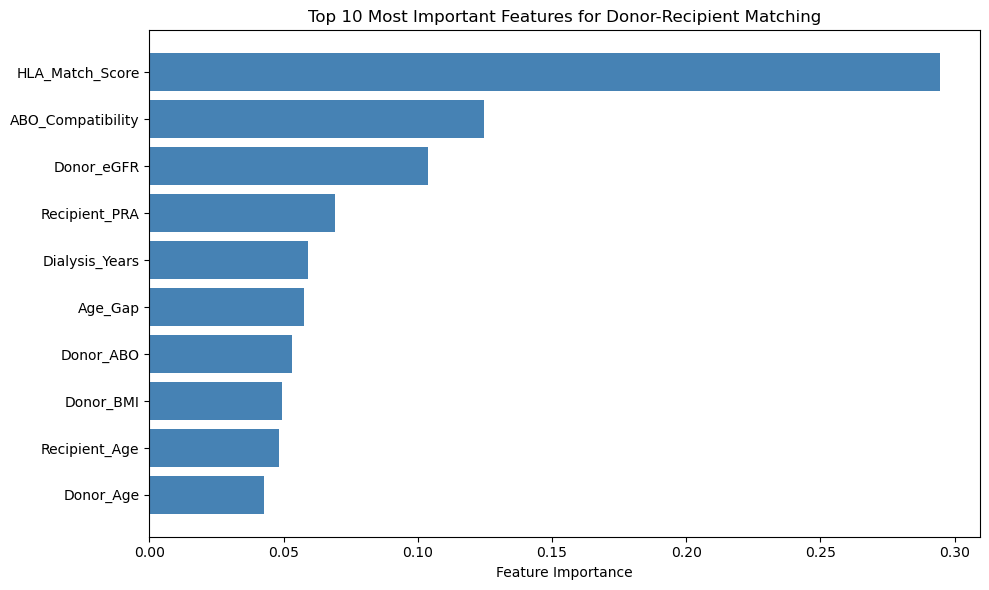

In [15]:
# Extract feature importances from Random Forest
# (Random Forest is always trained, regardless of which model was selected as best)

# Get feature names after preprocessing
feature_names_transformed = []

# Numeric features keep their names
feature_names_transformed.extend(numeric_features)

# Categorical features get one-hot encoded
if len(categorical_features) > 0:
    # Get the encoder from the pipeline
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    feature_names_transformed.extend(cat_feature_names)

# Get Random Forest classifier from pipeline
rf_classifier = model_pipeline.named_steps['classifier']

# Extract feature importances
importances = rf_classifier.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_transformed,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 10
print("="*70)
print("TOP 10 MOST IMPORTANT FEATURES (Random Forest)")
print("="*70)
print(feature_importance_df.head(10).to_string(index=False))
print("="*70)

# Visualize top 10
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(range(len(top_10)), top_10['Importance'], color='steelblue')
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Donor-Recipient Matching')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: feature_importance.png")
plt.show()

 10. Error Analysis and Clinical Safety



In [16]:

# Identify False Positives (predicted suitable but actually not suitable)
final_y_pred = final_model.predict(X_test)

fp_mask = (final_y_pred == 1) & (y_test == 0)
fp_indices = y_test[fp_mask].index

print("="*70)
print("FALSE POSITIVE ANALYSIS")
print("="*70)
print(f"Total False Positives: {fp_mask.sum()}")
print(f"Percentage of test set: {fp_mask.sum() / len(y_test) * 100:.2f}%")
print("-"*70)

if fp_mask.sum() > 0:
    # Get original data for false positives
    fp_samples = X_test.loc[fp_indices].head(5)
    fp_probs = final_y_probs[fp_mask][:5]
    
    print("\nSample of False Positive Cases (up to 5):")
    print("(Model predicted SUITABLE, but actually NOT SUITABLE)\n")
    
    for idx, (sample_idx, row) in enumerate(fp_samples.iterrows(), 1):
        print(f"Case {idx}:")
        print(f"  Predicted Probability: {fp_probs[idx-1]:.4f}")
        print(f"  Sample features (first 5):")
        for col in row.index[:5]:
            print(f"    {col}: {row[col]}")
        print()
    
    print("-"*70)
    
    # Identify False Negatives (predicted not suitable but actually suitable)
    fn_mask = (final_y_pred == 0) & (y_test == 1)
    
    print(f"\nTotal False Negatives: {fn_mask.sum()}")
    print(f"Percentage of test set: {fn_mask.sum() / len(y_test) * 100:.2f}%")
    
else:
    print("\nNo false positives found in test set.")

print("="*70)

FALSE POSITIVE ANALYSIS
Total False Positives: 46
Percentage of test set: 12.27%
----------------------------------------------------------------------

Sample of False Positive Cases (up to 5):
(Model predicted SUITABLE, but actually NOT SUITABLE)

Case 1:
  Predicted Probability: 0.5124
  Sample features (first 5):
    Donor_Age: 70.0
    Donor_BMI: 26.8
    Donor_eGFR: 93.0
    Donor_HTN: 1.0
    Donor_DM: 1.0

Case 2:
  Predicted Probability: 0.8816
  Sample features (first 5):
    Donor_Age: 28.0
    Donor_BMI: 29.8
    Donor_eGFR: 97.0
    Donor_HTN: 0.0
    Donor_DM: 0.0

Case 3:
  Predicted Probability: 0.8373
  Sample features (first 5):
    Donor_Age: 29.0
    Donor_BMI: 27.8
    Donor_eGFR: 93.0
    Donor_HTN: 0.0
    Donor_DM: 0.0

Case 4:
  Predicted Probability: 0.8834
  Sample features (first 5):
    Donor_Age: 33.0
    Donor_BMI: 27.4
    Donor_eGFR: 116.0
    Donor_HTN: 0.0
    Donor_DM: 0.0

Case 5:
  Predicted Probability: 0.5751
  Sample features (first 5):
    Dono